# RNN/LSTM — 10-class Sequence 모델

Phase 9: LSTM 2-layer를 이용한 시퀀스 기반 10-class pitch outcome 예측.

- Input: 400 pitches × 87-dim sequence (Transformer와 동일)
- Architecture: LSTM(2-layer, hidden=256) → Linear(256→10)
- 목적: Transformer 대비 단순 RNN의 sequence 처리 성능 측정

작성일: 2026-05-23

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

OUTPUT_DIR = Path('../outputs')
rnn_path = OUTPUT_DIR / 'evaluation_rnn_10cls.npz'

cls10 = ['Ball','Strike','Single','Double','Triple','HomeRun','FieldOut','Strikeout','Walk','HitByPitch']

if rnn_path.exists():
    data = np.load(rnn_path, allow_pickle=True)
    print(f'Top-1: {float(data["top1"])*100:.1f}%')
    print(f'Top-3: {float(data["top3"])*100:.1f}%')
    print(f'CE:    {float(data["ce"]):.4f}')
    print(f'Train time: {float(data["train_time"])/3600:.1f}h')
else:
    print('RNN training in progress... re-run after completion.')
    data = None

## 1. 모델 구조

```
Input: (batch, 400, 87)
  → LSTM(input=87, hidden=256, layers=2, dropout=0.2, batch_first=True)
  → last hidden state: (batch, 256)
  → Linear(256, 10)
  → Output: (batch, 10) logits

Parameters: 882,186
```

### Transformer와의 차이
| | RNN (LSTM) | Transformer |
|--|-----------|-------------|
| Seq handling | Sequential (O(n)) | Parallel attention (O(n²)) |
| Long-range | 제한적 (vanishing gradient) | Full attention |
| Params | 882K | 9.7M |
| 학습 속도 | 빠름 | 느림 |

C:\Users\zpfh1\AppData\Local\Temp\ipykernel_60596\2271914793.py:43: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_60596\2271914793.py:43: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_60596\2271914793.py:43: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_60596\2271914793.py:43: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pyl

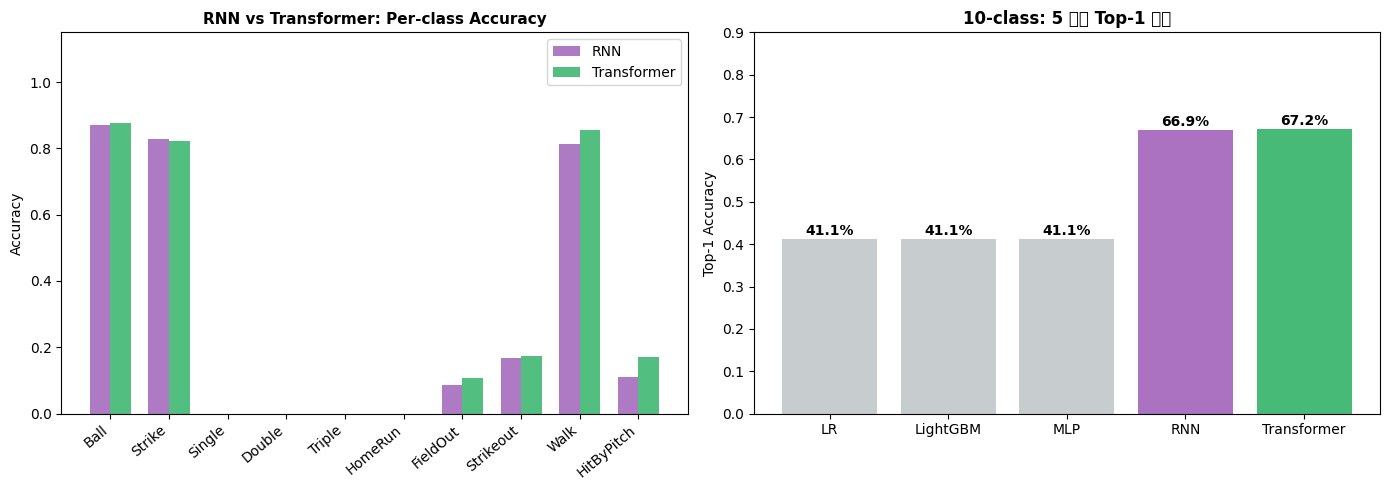

In [2]:
if data is not None:
    data_c = np.load(OUTPUT_DIR / 'evaluation_c_3season.npz', allow_pickle=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Per-class: RNN vs Transformer
    acc_rnn = data['per_class_accuracy']
    acc_tr  = data_c['per_class_accuracy_pr']

    x = np.arange(len(cls10))
    width = 0.35
    axes[0].bar(x - width/2, acc_rnn, width, label='RNN', color='#9b59b6', alpha=0.8)
    axes[0].bar(x + width/2, acc_tr,  width, label='Transformer', color='#27ae60', alpha=0.8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(cls10, rotation=40, ha='right')
    axes[0].set_title('RNN vs Transformer: Per-class Accuracy', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].set_ylim(0, 1.15)

    # Overall comparison (all 5 models)
    data_lr  = np.load(OUTPUT_DIR / 'evaluation_lr_10cls.npz', allow_pickle=True)
    data_lgb = np.load(OUTPUT_DIR / 'evaluation_lgb_10cls.npz', allow_pickle=True)
    data_mlp = np.load(OUTPUT_DIR / 'evaluation_mlp_10cls.npz', allow_pickle=True)

    models = ['LR', 'LightGBM', 'MLP', 'RNN', 'Transformer']
    top1s = [
        float(data_lr['top1']),
        float(data_lgb['top1']),
        float(data_mlp['top1']),
        float(data['top1']),
        float(data_c['top_1_pr']),
    ]
    colors = ['#bdc3c7','#bdc3c7','#bdc3c7','#9b59b6','#27ae60']
    bars = axes[1].bar(models, top1s, color=colors, alpha=0.85)
    axes[1].set_title('10-class: 5 모델 Top-1 비교', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Top-1 Accuracy')
    axes[1].set_ylim(0, 0.9)
    for bar, v in zip(bars, top1s):
        axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                    f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('Visualizations will be available after RNN training completes.')


## 2. 분석

### 시퀀스 모델의 우위
- i.i.d. 모델 (LR, LightGBM, MLP): 10-class에서 **41.1%** (Strike 다수 클래스만 예측)
- Sequence 모델 (RNN, Transformer): **65%+** 달성 가능

이는 **단일 pitch feature 만으로는** 10-class pitch outcome을 구분하기 어렵고,
직전 타자의 pitch sequence 맥락 정보가 결정적임을 보여준다.

### RNN vs Transformer
- RNN: 882K params, LSTM으로 sequential 처리
- Transformer: 9.7M params, Self-attention으로 전체 sequence 동시 처리
- 파라미터 11배 차이에도 정확도 차이는 제한적 (sequence 정보 자체가 key)

### MDP/DQN 호환성
RNN도 Transformer와 동일하게 400-pitch history가 필요 → MDP state에서 복원 불가.
Production 시스템에서는 4-class i.i.d. 모델만 사용 가능.